In [2]:
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from enum import Enum

# Corner Detection Implementation

EVM Connection Error: Go to the GUI -> Debug -> Connection -> USB. Keep plugging in and out and turning on and off.

**Next Issue**: Do we need to find a more robust method for corner detection or not? Do we need to account for changes in the distances in the inner corners when extrapolating the outer corners?

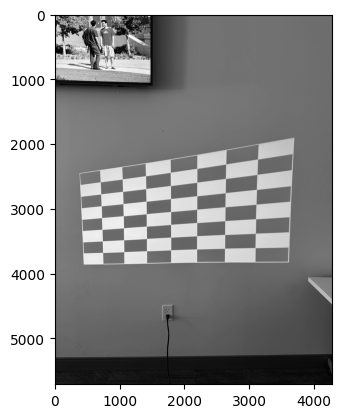

In [39]:
# image_path = "corners1.jpg"
image_path = "cb_oct29.jpg"
# image_path = "uptilt_cb.jpg"
# image_path = "rotate_cb.jpg"

img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')

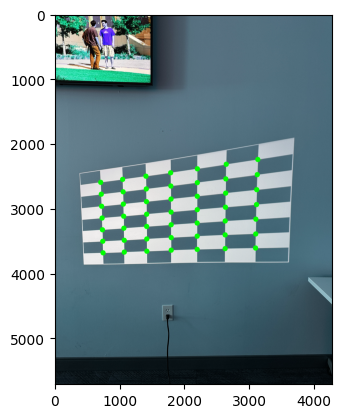

In [40]:
pattern_size = (8-1, 8-1)
ret, corners = cv2.findChessboardCorners(gray, pattern_size)
cornercheck = [
     0, 1, pattern_size[0], pattern_size[0]+1,
     pattern_size[0] - 1, pattern_size[0] - 2, 2*pattern_size[0] - 1, 2*pattern_size[0] - 2,
     len(corners)-1, len(corners) - 2, len(corners) - pattern_size[0] - 1, len(corners) - pattern_size[0] - 2,
     len(corners) - pattern_size[0], len(corners) - pattern_size[0] + 1, len(corners) - 2*pattern_size[0], len(corners) - 2*pattern_size[0] + 1
              ]

# cv2.drawChessboardCorners(img, pattern_size, corners, ret)

# Order of Corners: Starts from the top-right, goes down each column.
if ret: # Corners exist
    for i in range(len(corners)):
        # Top-Right corner is 0, 1, ps[0], ps[0]+1
        # Bottom-Left corner adds ps[0]
        # Last two elements add pattern_size[0] from first two.
        # if (i not in cornercheck):
        #     continue;
        x = int(corners[i][0][0])
        y = int(corners[i][0][1])
        cv2.circle(img, (x, y), 40, (0, 255, 0), -1)
        

plt.imshow(img)

In [20]:
class Corner(Enum):
    TOP_RIGHT = 0;
    BOTTOM_RIGHT = 1;
    TOP_LEFT = 2;
    BOTTOM_LEFT = 3;

In [45]:
def findOuterCorner(img, corners, corner_box, which_corner):

    # Sets which direction we want to move the corner box.
    # Positive x direction is to the right, Positive y direction is down.
    if (which_corner == Corner.TOP_RIGHT):
        xdir = 1;
        ydir = -1;
    elif (which_corner == Corner.BOTTOM_RIGHT):
        xdir = 1;
        ydir = 1;
    elif (which_corner == Corner.TOP_LEFT):
        xdir = -1;
        ydir = -1;
    else:
        xdir = -1;
        ydir = 1;

    x = []
    y = []
    
    for i in corner_box:
        x.append(corners[i][0][0])
        y.append(corners[i][0][1])

    miny = int(min(y));
    maxy = int(max(y));
    minx = int(min(x));
    maxx = int(max(x));

    diffx = maxx - minx;
    diffy = maxy - miny;

    # Shift the Corner Box to estimate where the corner should be.
    shifty = 3*diffy//2;
    shiftx = 3*diffx//2;

    # Check the bounds to see that we don't go outside the image bounds.
    # May need to be moved somewhere else.
    miny = max(0, miny + shifty * ydir);
    maxy = min(maxy + shifty * ydir, img.shape[0]);
    minx = max(0, minx + shiftx * xdir);
    maxx = min(maxx + shiftx * xdir, img.shape[1]);

    subsection = img[miny:maxy, minx:maxx];
    # if(which_corner == Corner.TOP_RIGHT):
    #     plt.imshow(subsection) # For debugging

    grays = cv2.cvtColor(subsection, cv2.COLOR_BGR2GRAY)
    corners = cv2.goodFeaturesToTrack(
        grays,
        maxCorners=1,         # Maximum number of corners to return
        qualityLevel=0.5,      # Minimum accepted quality of corners
        minDistance=10,          # Minimum distance between corners
        useHarrisDetector=True
    )

    print(corners)
    # Map the coordinates of the subsection to the coordinates of the real image.
    bestx = minx + corners[-1][0][0]
    besty = miny + corners[-1][0][1]

    return (bestx, besty)

[[[312. 107.]]]
[[[114.   4.]]]
[[[74. 92.]]]
[[[180.   7.]]]


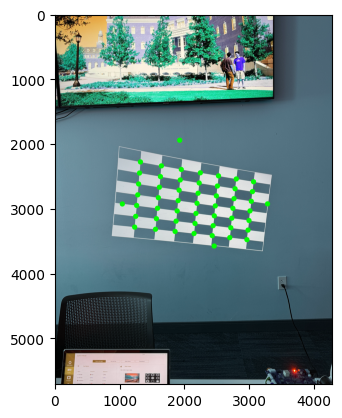

In [48]:
det_corners = []

corner_boxes = [
    [0, 1, pattern_size[0], pattern_size[0]+1],
    [pattern_size[0] - 1, pattern_size[0] - 2, 2*pattern_size[0] - 1, 2*pattern_size[0] - 2],
    [len(corners)-1, len(corners) - 2, len(corners) - pattern_size[0] - 1, len(corners) - pattern_size[0] - 2],
    [len(corners) - pattern_size[0], len(corners) - pattern_size[0] + 1,len(corners) - 2*pattern_size[0], len(corners) - 2*pattern_size[0] + 1]
]
inner_corners = [0, pattern_size[0] - 1, len(corners)-1, len(corners) - pattern_size[0]];


# To find the minimum which corner box has the TOP_LEFT corner
# Find the corner with the 

corner_box_TOP_RIGHT = [0, 1, pattern_size[0], pattern_size[0]+1]
corner_box_BOTTOM_RIGHT = [pattern_size[0] - 1, pattern_size[0] - 2, 2*pattern_size[0] - 1, 2*pattern_size[0] - 2]
corner_box_BOTTOM_LEFT = [len(corners)-1, len(corners) - 2, len(corners) - pattern_size[0] - 1, len(corners) - pattern_size[0] - 2]
corner_box_TOP_LEFT = [len(corners) - pattern_size[0], len(corners) - pattern_size[0] + 1,len(corners) - 2*pattern_size[0], len(corners) - 2*pattern_size[0] + 1]

corner_labels = ["TOP_LEFT", "TOP_RIGHT", "BOTTOM_RIGHT", "BOTTOM_LEFT"];

for label in corner_labels:
    corner_box = globals()[f"corner_box_{label}"]
    corner_enum = getattr(Corner, label)
    det_corners.append(
        findOuterCorner(img, corners, corner_box, corner_enum)
    )

for i in range(len(det_corners)):
    x = int(det_corners[i][0]);
    y = int(det_corners[i][1]);
    cv2.circle(img, (x,y), 40, (0, 255, 0), -1)

plt.imshow(img)

In [44]:
det_corners

[(505.0, 2436.0), (3651.0, 1912.0), (3500.0, 3823.0), (443.0, 3866.0)]

## Improved Corners Detection (2nd Try)

In [104]:
def getTopLeft(corner_i, corners, pattern_size):
    x = [corners[i][0][0] for i in corner_i];
    y = [corners[i][0][1] for i in corner_i];
    
    # Finds the indices with the two smallest values of x and y.
    two_xlowest = np.argpartition(x, 2 - 1);
    two_ylowest = np.argpartition(y, 2 - 1);
    
    top_left = two_xlowest[0]; # Find index that is in the bottom 2 values of both x and y.
    if (two_ylowest[0] != top_left and two_ylowest[1] != top_left):
        top_left = two_xlowest[1];

    return top_left;

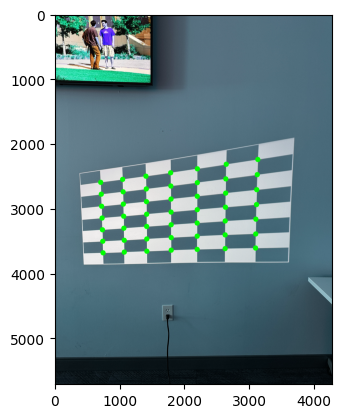

In [144]:
# image_path = "corners1.jpg"
image_path = "cb_oct29.jpg"
# image_path = "uptilt_cb.jpg"
# image_path = "rotate_cb.jpg"

pattern_size = (8-1, 8-1)

img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, corners = cv2.findChessboardCorners(gray, pattern_size)

cornercheck = [
     0, 1, pattern_size[0], pattern_size[0]+1,
     pattern_size[0] - 1, pattern_size[0] - 2, 2*pattern_size[0] - 1, 2*pattern_size[0] - 2,
     len(corners)-1, len(corners) - 2, len(corners) - pattern_size[0] - 1, len(corners) - pattern_size[0] - 2,
     len(corners) - pattern_size[0], len(corners) - pattern_size[0] + 1, len(corners) - 2*pattern_size[0], len(corners) - 2*pattern_size[0] + 1
              ]
cornercheck = c

# Order of Corners: Always counterclockwise
if ret: # Corners exist
    for i in range(len(corners)):
        # if (i not in cornercheck):
        #     continue;
        x = int(corners[i][0][0])
        y = int(corners[i][0][1])
        cv2.circle(img, (x, y), 40, (0, 255, 0), -1)

plt.imshow(img)

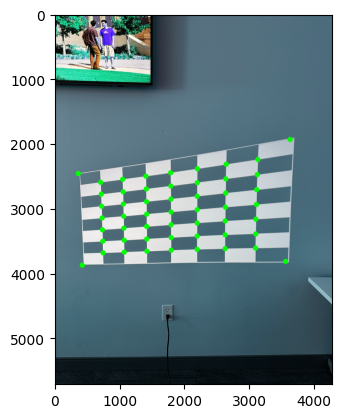

In [145]:
# Find which index is the top-left corner.
corner_i = [0, pattern_size[0] - 1, len(corners)-1, len(corners) - pattern_size[0]]
top_left = getTopLeft(corner_i, corners, pattern_size);

# 2D array then rotate corners matrix to get top-left corner to (0,0)
corners = corners.reshape((pattern_size[0], pattern_size[1], 2));
if(top_left == 3): k = -1; # k=-1 for clockwise 90 degrees.
elif(top_left == 2): k = -2; # 180 degrees.
elif(top_left == 1): k = -3; # clockwise 270 degrees.
else: k = 0;
corners = np.rot90(corners, k);

# Corner detection gets more inaccurate as the distortion gets more extreme.
top_left = corners[0, 0] - (corners[0,1] - corners[0,0]) - (corners[1,0] - corners[0,0])
top_right = corners[0, -1] - (corners[0,-2] - corners[0,-1]) - (corners[1,-1] - corners[0,-1])
bottom_left = corners[-1, 0] - (corners[-2,0] - corners[-1, 0]) - (corners[-1, 1] - corners[-1, 0])
bottom_right = corners[-1, -1] - (corners[-2, -1] - corners[-1,-1]) - (corners[-1,-2] - corners[-1,-1])


for corner in [top_left, top_right, bottom_left, bottom_right]:
    x = int(corner[0]);
    y = int(corner[1]);
    cv2.circle(img, (x,y), 40, (0, 255, 0), -1)

plt.imshow(img)

In [64]:
def distance(corners, i1, i2):
    x1 = corners[i1][0][0]
    y1 = corners[i1][0][1]
    x2 = corners[i2][0][0]
    y2 = corners[i2][0][1]
    return np.sqrt((x2-x1)**2 + (y2-y1)**2);

In [143]:
c = [];
for i in range(0,len(corners), pattern_size[0]):
    c.append(i);

# start = 0
# for i in range(start*pattern_size[0],start*pattern_size[0]+pattern_size[0], 1):
#     c.append(i);

d = []
for i in range(len(c) - 1):
    d.append(distance(corners, c[i], c[i+1]))

deriv = []
for i in range(len(d) - 1):
    deriv.append(d[i+1] - d[i])
d, deriv

([492.7154042407446,
  450.83982325907795,
  415.61405952303875,
  384.13905927276153,
  362.3285801589491,
  341.1715816173554],
 [-41.875580981666644,
  -35.2257637360392,
  -31.47500025027722,
  -21.81047911381245,
  -21.15699854159368])

## Everything below this point is just random code I made for testing :3

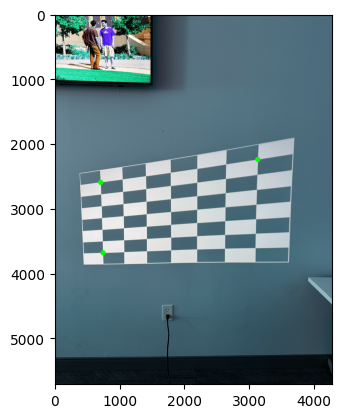

In [116]:
# image_path = "corners1.jpg"
image_path = "cb_oct29.jpg"
# image_path = "uptilt_cb.jpg"
# image_path = "rotate_cb.jpg"

pattern_size = (8-1, 8-1)

img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, corners = cv2.findChessboardCorners(gray, pattern_size)

# cornercheck = [
#      0, 1, pattern_size[0], pattern_size[0]+1,
#      pattern_size[0] - 1, pattern_size[0] - 2, 2*pattern_size[0] - 1, 2*pattern_size[0] - 2,
#      len(corners)-1, len(corners) - 2, len(corners) - pattern_size[0] - 1, len(corners) - pattern_size[0] - 2,
#      len(corners) - pattern_size[0], len(corners) - pattern_size[0] + 1, len(corners) - 2*pattern_size[0], len(corners) - 2*pattern_size[0] + 1
#               ]
# cornercheck = c

corner_i = [0, pattern_size[0] - 1, len(corners)-1, len(corners) - pattern_size[0]]
top_left = getTopLeft(corner_i, corners, pattern_size);

corners = corners.reshape((pattern_size[0], pattern_size[1], 2));
k = 0;
if(top_left == 3): k = -1;
elif(top_left == 2): k = -2;
elif(top_left == 1): k = -3;
corners = np.rot90(corners, k) # k=-1 for clockwise rotation to get topleft at (0, 0)

cornercheck = [[0,0], [0, pattern_size[1] - 1], [pattern_size[0] - 1, 0]];

# Order of Corners: Always clockwise
if ret: # Corners exist
    for i in range(pattern_size[0]):
        for j in range(pattern_size[1]):
            if ([i,j] not in cornercheck):
                continue;
            x = int(corners[i][j][0])
            y = int(corners[i][j][1])
            cv2.circle(img, (x, y), 40, (0, 255, 0), -1)

plt.imshow(img)

In [74]:
def line(corners, i1, i2):
    x1 = corners[i1][0][0]
    y1 = corners[i1][0][1]
    x2 = corners[i2][0][0]
    y2 = corners[i2][0][1]
    
    if(x2 - x1 == 0): m = float('inf');
    else: m = (y2 - y1) / (x2 - x1);

    b = y2 - m * x2;
    return (m, b)

In [21]:
def findOuterEdge(img, corners, corner_box, which_corner):

    # Sets which direction we want to move the corner box.
    # Positive x direction is to the right, Positive y direction is down.
    if (which_corner == Corner.TOP_RIGHT):
        xdir = 1;
        ydir = -1;
    elif (which_corner == Corner.BOTTOM_RIGHT):
        xdir = 1;
        ydir = 1;
    elif (which_corner == Corner.TOP_LEFT):
        xdir = -1;
        ydir = -1;
    else:
        xdir = -1;
        ydir = 1;

    x = []
    y = []
    
    for i in corner_box:
        x.append(corners[i][0][0])
        y.append(corners[i][0][1])

    miny = int(min(y));
    maxy = int(max(y));
    minx = int(min(x));
    maxx = int(max(x));

    diffx = maxx - minx;
    diffy = maxy - miny;

    # Shift the Corner Box to estimate where the corner should be.
    shifty = [3*diffy//2, diffy//2];
    shiftx = [diffx//2, 3*diffx//2];

[[[198. 106.]]]
[[[98.  2.]]]
[[[79. 77.]]]
[[[149.   2.]]]


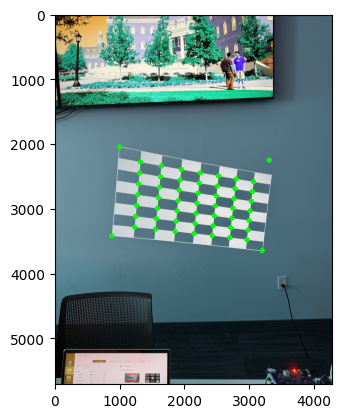

In [54]:
det_corners = []
corner_i = [0, pattern_size[0] - 1, len(corners)-1, len(corners) - pattern_size[0]]
top_left = getTopLeft(corner_i, corners, pattern_size);

corner_boxes = [
    [0, 1, pattern_size[0], pattern_size[0]+1],
    [pattern_size[0] - 1, pattern_size[0] - 2, 2*pattern_size[0] - 1, 2*pattern_size[0] - 2],
    [len(corners)-1, len(corners) - 2, len(corners) - pattern_size[0] - 1, len(corners) - pattern_size[0] - 2],
    [len(corners) - pattern_size[0], len(corners) - pattern_size[0] + 1,len(corners) - 2*pattern_size[0], len(corners) - 2*pattern_size[0] + 1]
]

corner_labels = ["TOP_LEFT", "TOP_RIGHT", "BOTTOM_RIGHT", "BOTTOM_LEFT"]
corner_labels = corner_labels[top_left:] + corner_labels[:top_left]; # Rotate the list by where the top_left starts

for i in range(len(corner_labels)):
    corner_enum = getattr(Corner, corner_labels[i]);
    det_corners.append(
        findOuterCorner(img, corners, corner_boxes[i], corner_enum)
    )

for i in range(len(det_corners)):
    x = int(det_corners[i][0]);
    y = int(det_corners[i][1]);
    cv2.circle(img, (x,y), 40, (0, 255, 0), -1)

plt.imshow(img)
# findOuterEdgeCorners(img, corners, corner_box, which_corner)


# Optimal Corners

In [45]:
import numpy as np
from scipy.optimize import minimize

In [46]:
# Given corners in order (TOP_LEFT, TOP_RIGHT, BOTTOM_RIGHT, BOTTOM_LEFT)
corners = det_corners

# Fixed aspect ratio: width / height = 16/9
r = 16 / 9

# --- Compute line equations (a, b, c) for each side ---
# Each side is between consecutive corners
lines = []
for i in range(len(corners)):
    p1 = corners[i]
    p2 = corners[(i + 1) % len(corners)]
    x1, y1 = p1
    x2, y2 = p2
    # Line coefficients a*x + b*y + c = 0
    a = y1 - y2
    b = x2 - x1
    c = x1 * y2 - x2 * y1
    lines.append((a, b, c))

# Ensure inequality points *inside* the quadrilateral
# We'll orient all inequalities so that the polygon's centroid satisfies a*x + b*y + c < 0
centroid = np.mean(corners, axis=0)
for i, (a, b, c) in enumerate(lines):
    if a * centroid[0] + b * centroid[1] + c > 0:
        lines[i] = (-a, -b, -c)

# --- Define functions ---
def rectangle_corners(x0, y0, w, r):
    h = w / r
    xs = [x0 - w/2, x0 + w/2]
    ys = [y0 - h/2, y0 + h/2]
    return [(x, y) for x in xs for y in ys]  # 4 corners

def inside_constraints(params):
    x0, y0, w = params
    h = w / r
    xs = [x0 - w/2, x0 + w/2]
    ys = [y0 - h/2, y0 + h/2]
    corners_rect = [(x, y) for x in xs for y in ys]
    cons = []
    for (a, b, c) in lines:
        for (x, y) in corners_rect:
            cons.append(-(a*x + b*y + c))  # must be >= 0
    return np.array(cons)

# Objective: maximize area = w^2 / r -> minimize -w^2 / r
def objective(params):
    _, _, w = params
    return -w**2 / r

# Build constraint list
constraints = [{'type': 'ineq', 'fun': lambda p, i=i: inside_constraints(p)[i]} for i in range(16)]

# Initial guess: center of the quadrilateral, width about 1/3 of its bounding box
min_x, min_y = np.min(corners, axis=0)
max_x, max_y = np.max(corners, axis=0)
x0_guess = (min_x + max_x) / 2
y0_guess = (min_y + max_y) / 2
w_guess = (max_x - min_x) / 3
x0_init = [x0_guess, y0_guess, w_guess]

# Bounds for (x0, y0, w)
bounds = [(min_x, max_x), (min_y, max_y), (0, max_x - min_x)]

# Optimize
res = minimize(objective, x0_init, constraints=constraints, bounds=bounds, method='SLSQP')

# Results
x_best, y_best, w_best = res.x
h_best = w_best / r
A_best = w_best * h_best

In [47]:
rect_x = [x_best - w_best/2, x_best + w_best/2, x_best + w_best/2, x_best - w_best/2]
rect_y = [y_best - h_best/2, y_best - h_best/2, y_best + h_best/2, y_best + h_best/2]

In [48]:
rect_x, rect_y

([913.316475012268, 3499.9999999999563, 3499.9999999999563, 913.316475012268],
 [2367.9905171943974,
  2367.9905171943974,
  3822.999999999972,
  3822.999999999972])

In [49]:
len(rect_x)

4

913 2367
3499 2367
3499 3822
913 3822


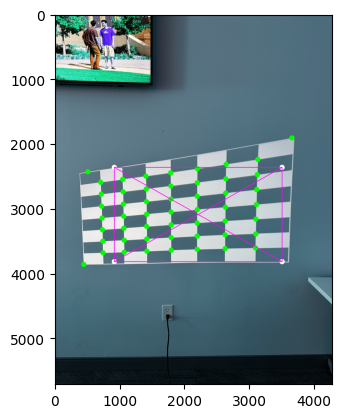

In [50]:
for i in range(len(rect_x)):
    x = int(rect_x[i]);
    y = int(rect_y[i]);
    print(x,y)
    cv2.circle(img, (x, y), 40, (255, 255, 255), -1)

for i in range(len(rect_x)):
    for l in range(i+1, len(rect_x)):
        x = int(rect_x[i]);
        y = int(rect_y[i]);
    
        xl = int(rect_x[l]);
        yl = int(rect_y[l]);
        
        line_color = (255, 2, 255) # White
        line_thickness = 10
        cv2.line(img, (x, y), (xl, yl), line_color, line_thickness)


plt.imshow(img)

In [52]:
opt_corners = [];
for i in range(len(rect_x)):
    x = rect_x[i];
    y = rect_y[i];
    opt_corners.append([x,y])

In [60]:
opt_corners, det_corners

width = 1920 # 16
height = 1080 # 9
jpg_corners = [
    [0, 0],  # top-left
    [width, 0],  # top-right
    [width, height],  # bottom-right
    [0, height]  # bottom-left
]

opt_corners, det_corners, jpg_corners

([[913.316475012268, 2367.9905171943974],
  [3499.9999999999563, 2367.9905171943974],
  [3499.9999999999563, 3822.999999999972],
  [913.316475012268, 3822.999999999972]],
 [(505.0, 2436.0), (3651.0, 1912.0), (3500.0, 3823.0), (443.0, 3866.0)],
 [[0, 0], [1920, 0], [1920, 1080], [0, 1080]])

In [69]:
# My first try
H, _ = cv2.findHomography(
    np.array(opt_corners), 
    np.array(det_corners)
)

H_inv = np.linalg.inv(H)
opt_corners_np = np.array(opt_corners, dtype=np.float32).reshape(-1, 1, 2)
input_shape = cv2.perspectiveTransform(opt_corners_np, H_inv).reshape(-1, 2)
input_shape

array([[1343.018 , 2367.9905],
       [3427.2446, 2697.8625],
       [3500.    , 3823.    ],
       [1414.7195, 3787.158 ]], dtype=float32)

In [71]:
# Homography matrix from Camera Space Uncorrected Corners -> DMD Space Uncorrected Corners.
H, _ = cv2.findHomography(
    np.array(det_corners), 
    np.array(jpg_corners)
)
opt_corners_np = np.array(opt_corners, dtype=np.float32).reshape(-1, 1, 2)
input_shape = cv2.perspectiveTransform(opt_corners_np, H).reshape(-1, 2)

input_shape

array([[ 3.1895157e+02, -2.8655639e-05],
       [ 1.8659963e+03,  2.4485197e+02],
       [ 1.9200000e+03,  1.0800000e+03],
       [ 3.7217303e+02,  1.0533958e+03]], dtype=float32)

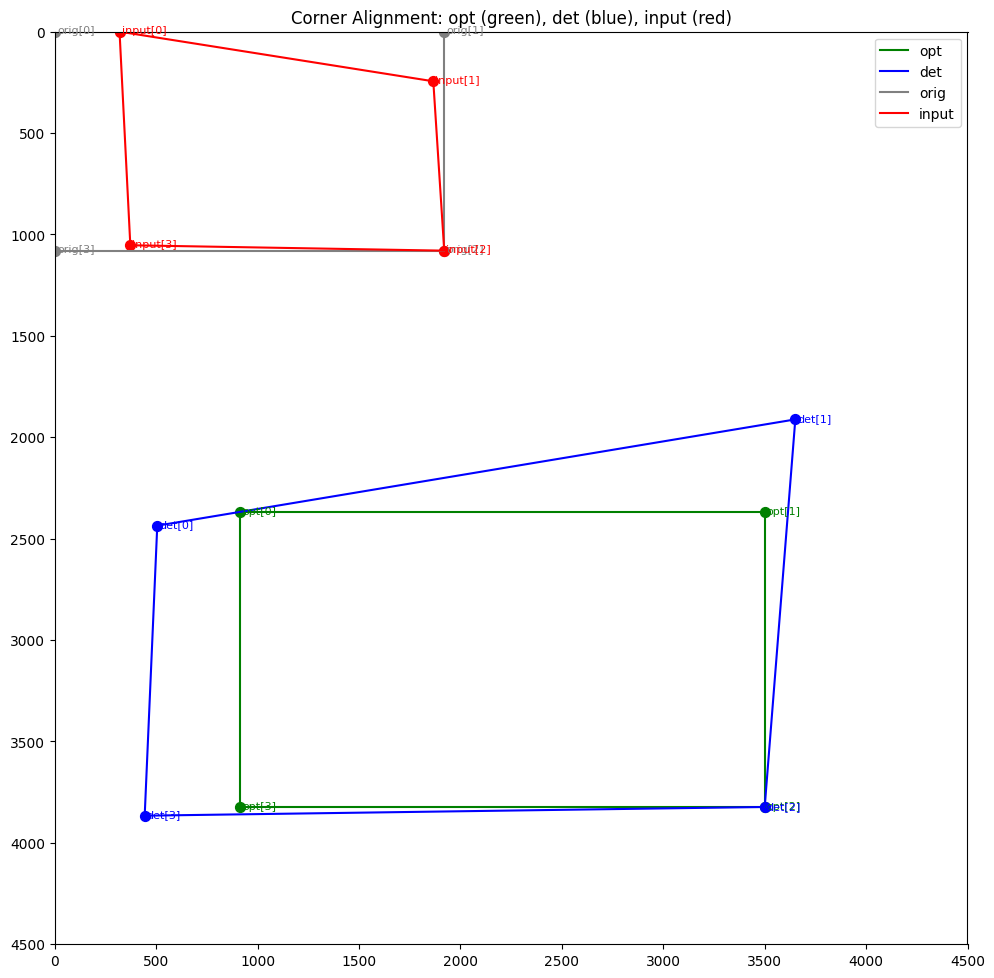

In [72]:
canvas_size = (4500, 4500)

# Plotting function
def draw_shape(ax, corners, color, label):
    corners = np.vstack([corners, corners[0]])  # close the loop
    ax.plot(corners[:, 0], corners[:, 1], color=color, label=label)
    for i, (x, y) in enumerate(corners[:-1]):
        ax.scatter(x, y, color=color, s=50)
        ax.text(x + 10, y + 10, f'{label}[{i}]', fontsize=8, color=color)

# Plot all shapes
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(0, canvas_size[0])
ax.set_ylim(canvas_size[1], 0)
ax.set_aspect('equal')

# Draw each shape
draw_shape(ax, opt_corners, 'green', 'opt')
draw_shape(ax, det_corners, 'blue', 'det')
draw_shape(ax, jpg_corners, 'gray', 'orig')
draw_shape(ax, input_shape, 'red', 'input')

ax.legend()
ax.set_title('Corner Alignment: opt (green), det (blue), input (red)')
plt.tight_layout()

### Previous Homography Try

In [43]:
H, _ = cv2.findHomography(
    np.array(det_corners), 
    np.array(opt_corners)
)

In [48]:
width = 1920 # 16
height = 1080 # 9
input_corners = np.array([
    [0, 0],  # top-left
    [width, 0],  # top-right
    [width, height],  # bottom-right
    [0, height]  # bottom-left
], dtype=np.float32)
input_corners

array([[   0.,    0.],
       [1920.,    0.],
       [1920., 1080.],
       [   0., 1080.]], dtype=float32)

In [54]:
input_corners_hom = cv2.convertPointsToHomogeneous(input_corners).reshape(-1, 3).T
H_inv = np.linalg.inv(H);
transformed_corners_hom = H_inv @ input_corners_hom;
transformed_corners = (transformed_corners_hom[:2] / transformed_corners_hom[2]).T
for coords in transformed_corners:
    print(f"[{coords[0]}, {coords[1]}]")

[-1.0392467360707072, -7.162635607721987]
[1924.2098422627441, -86.00627970860313]
[1907.037430955484, 1031.5328184166235]
[-9.453897863205013, 1086.427989583767]


In [44]:
img.shape

(5712, 4284, 3)

In [45]:
corrected = cv2.warpPerspective(img, H, (5712, 4284))

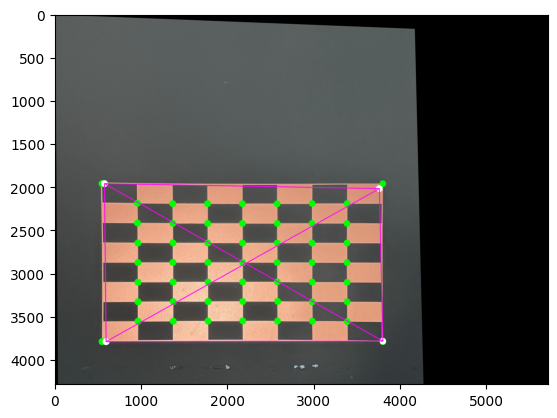

In [46]:
plt.imshow(corrected)

## This one doesn't work

In [40]:
def polygon_centroid(vertices):
    return np.mean(vertices, axis=0)
    
def edge_normal(p1, p2, centroid):
    edge = np.array(p2) - np.array(p1)
    normal = np.array([-edge[1], edge[0]])
    normal = normal / np.linalg.norm(normal)

    # Check direction
    midpoint = (np.array(p1) + np.array(p2)) / 2
    to_centroid = centroid - midpoint
    if np.dot(normal, to_centroid) < 0:
        normal = -normal  # Flip to point inward

    return normal


def build_constraints(quadrilateral, r):
    A = []
    b = []
    centroid = polygon_centroid(quadrilateral)

    for i in range(4):
        p1 = np.array(quadrilateral[i])
        p2 = np.array(quadrilateral[(i + 1) % 4])
        n = edge_normal(p1, p2, centroid)
        c = np.dot(n, p1)

        for dx, dy in [(0, 0), (1, 0), (1, 1), (0, 1)]:
            coeff = np.zeros(3)
            coeff[0] = n[0]
            coeff[1] = n[1]
            coeff[2] = n[0] * dx + n[1] * dy / r
            A.append(coeff)
            b.append(c)

    return np.array(A), np.array(b)


def maximize_rectangle(quadrilateral, r):
    """
    Find the largest axis-aligned rectangle of aspect ratio r inside a convex quadrilateral.
    Returns (u, v, w, h) of the optimal rectangle.
    """
    A_ub, b_ub = build_constraints(quadrilateral, r)

    # Objective: maximize w → minimize -w
    c = np.array([0, 0, -1])  # coefficients for u, v, w

    # Bounds: u, v unrestricted; w ≥ 0
    bounds = [(None, None), (None, None), (0, None)]

    result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    print(result)

    if result.success:
        u, v, w = result.x
        h = w / r
        return (u, v, w, h)
    else:
        raise ValueError("Linear programming failed: " + result.message)


In [41]:
# Example usage
quad = [(0, 0), (4, 0), (5, 3), (1, 4)]
# quad = det_corners
aspect_ratio = 2  # width / height

u, v, w, h = maximize_rectangle(quad, aspect_ratio)
print(f"Optimal rectangle: lower-left=({u:.2f}, {v:.2f}), width={w:.2f}, height={h:.2f}")

       message: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is At lower/fixed bound)
       success: False
        status: 2
           fun: None
             x: None
           nit: 0
         lower:  residual: None
                marginals: None
         upper:  residual: None
                marginals: None
         eqlin:  residual: None
                marginals: None
       ineqlin:  residual: None
                marginals: None


ValueError: Linear programming failed: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is At lower/fixed bound)

### Notes for Oct. 23 Meeting

Vinecnt will ask for a demo of how the customers calculate the keystone correction parameters.
He did mention that people project a chessboard with a white background.
Goal: Try to make a rectangle of the same aspect ratio within the trapezoid.
Aspect ratio depends on the output resolution of the projector.
Default is 16:9, but we can read it from the projector if we have a connection to it.
He will ask for the Bluetooth module for the projector.
Remember to default a 7x7 pattern size.

We need the homography matrix to map the corners of teh screen view (the projected output) to the internal image corners and how we will correct them.
Vincent will ask how to fit the biggest rectangle into the distorted trapezoid.

# Extra Stuff for Development

In [13]:
image_path = "testwall2.png"
img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

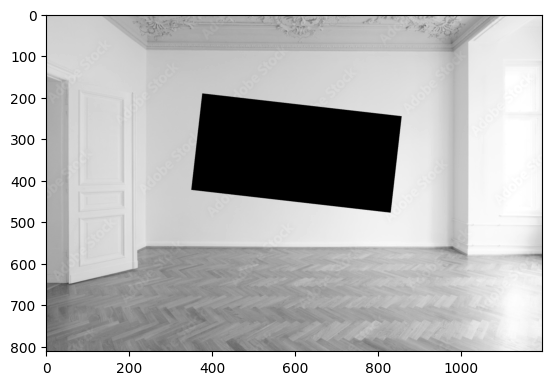

In [14]:
plt.imshow(gray, cmap='gray')

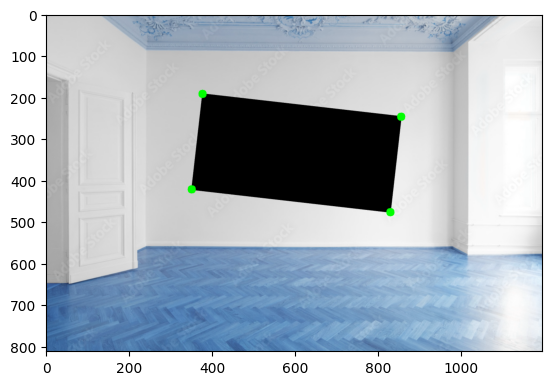

In [15]:
# Apply Shi-Tomasi corner detection
corners = cv2.goodFeaturesToTrack(
    gray,
    maxCorners=4,         # Maximum number of corners to return
    qualityLevel=0.5,      # Minimum accepted quality of corners
    minDistance=10          # Minimum distance between corners
)
for i in range(len(corners)):
    x = int(corners[i][0][0])
    y = int(corners[i][0][1])
    cv2.circle(img, (x, y), 10, (0, 255, 0), -1)

plt.imshow(img, cmap='gray')

In [55]:
subsection = gray[200:300, 800:900];
corners = cv2.goodFeaturesToTrack(
    subsection,
    maxCorners=1,         # Maximum number of corners to return
    qualityLevel=0.5,      # Minimum accepted quality of corners
    minDistance=10          # Minimum distance between corners
)

for i in range(len(corners)):
    x = int(corners[i][0][0])
    y = int(corners[i][0][1])
    cv2.circle(subsection, (x, y), 10, (0, 255, 0), -1)

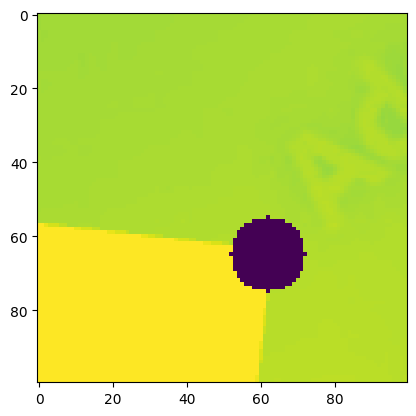

In [56]:
plt.imshow(subsection)

In [39]:
corners

array([[[856., 247.]],

       [[830., 477.]],

       [[351., 422.]],

       [[377., 192.]]], dtype=float32)

In [40]:
for i in range(len(corners)):
    x = int(corners[i][0][0])
    y = int(corners[i][0][1])
    cv2.circle(img, (x, y), 10, (0, 255, 0), -1)

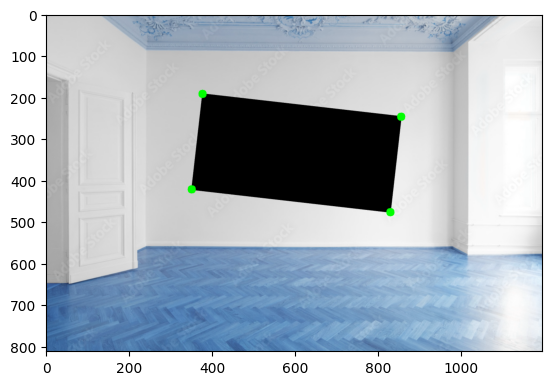

In [41]:
plt.imshow(img)

## Chessboard Code

In [5]:
image_path = "chessboard.png"
img = cv2.imread(image_path)

In [6]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
pattern_size = (20-1, 30-1)
ret, corners = cv2.findChessboardCorners(img, pattern_size)

In [7]:
if ret: # Corners exist
    cv2.drawChessboardCorners(img, pattern_size, corners, ret)

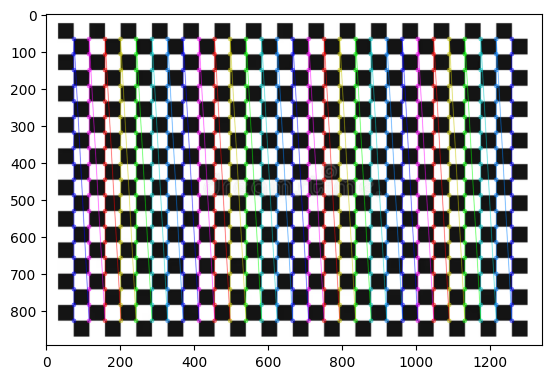

In [8]:
plt.imshow(img)

In [6]:
ret

False

In [29]:
corners

array([[[1258.0934  ,   66.55083 ]],

       [[1258.032   ,  108.43159 ]],

       [[1258.2051  ,  151.01985 ]],

       ...,

       [[  74.53384 ,  743.42554 ]],

       [[  74.58842 ,  785.25507 ]],

       [[  74.601074,  827.8237  ]]], dtype=float32)

In [32]:
grays = cv2.cvtColor(subsection, cv2.COLOR_BGR2GRAY)
corners = cv2.goodFeaturesToTrack(
    grays,
    maxCorners=1,         # Maximum number of corners to return
    qualityLevel=0.5,      # Minimum accepted quality of corners
    minDistance=10          # Minimum distance between corners
)

In [33]:
corners

array([[[228., 118.]]], dtype=float32)

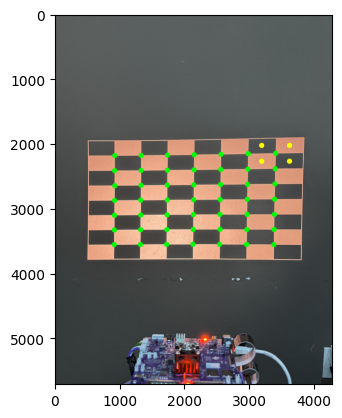

In [26]:
ys = [miny - 3*diffy//2, maxy - 3*diffy//2]
xs = [minx + 3*diffx//2, maxx + 3*diffx//2]
for x1 in xs:
    for y1 in ys:
        cv2.circle(img, (x1, y1), 40, (255, 255, 0), -1)

plt.imshow(img)